## 📌 About this project
* This project predicts Lead Conversion — whether a customer who visits Stuffmart.com will eventually make a purchase (Hot Lead) or not (Cold Lead).

* The pipeline follows the standard ML workflow:

* Data cleaning — duplicates, missing values, outliers (IQR + Z-score)
* Exploratory Data Analysis (EDA) — distributions, correlations
* Feature selection — noisy / low-impact columns removed
* Preprocessing — imputation + ordinal encoding via ColumnTransformer
* Model selection — RandomizedSearchCV over Decision Tree, Random Forest and KNN
* Evaluation — accuracy, precision, recall, F1, confusion matrix

## `Phase 01 — Load and Understand the Dataset`

***Import Libraries***

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
import chardet
import joblib

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import sklearn.metrics as skm
import sklearn.preprocessing as skp
from sklearn import model_selection as ms 

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

***Read the dataset***

In [62]:
import kagglehub

# Download latest version
try:
    path = kagglehub.dataset_download("muhammadshahidazeem/customer-conversion-dataset-for-stuffmart-com")
    
    df = pd.read_csv(f"{path}/customer_conversion_traing_dataset.csv")

    test_data = pd.read_csv(f"{path}/customer_conversion_testing_dataset.csv") 
    
    print("Path to dataset files:", path)
    
except:
    # This block runs when dataset does not download from kaggle and read the downloaded dataset locally
    df = pd.read_csv(f"customer_conversion_traing_dataset.csv")

    test_data = pd.read_csv(f"customer_conversion_testing_dataset.csv")
    
    print("Read Dataset Locally")

Path to dataset files: C:\Users\SHAH COMPUTERS\.cache\kagglehub\datasets\muhammadshahidazeem\customer-conversion-dataset-for-stuffmart-com\versions\1


***Check Dataset Encoding Scheme***

In [63]:
with open(f"{path}/customer_conversion_traing_dataset.csv", "rb") as f:
    raw = f.read(10000)
    result = chardet.detect(raw)
result

{'encoding': 'ascii',
 'confidence': 1.0,
 'language': 'eo',
 'mime_type': 'text/plain'}

## `Phase 02 — Initial Dataset Inspection`

***Dataset Insights***

In [64]:
df.shape

(100000, 19)

In [65]:
df.head()

,LeadID,Age,Gender,Location,LeadSource,TimeSpent (minutes),PagesViewed,LeadStatus,EmailSent,DeviceType,ReferralSource,FormSubmissions,Downloads,CTR_ProductPage,ResponseTime (hours),FollowUpEmails,SocialMediaEngagement,PaymentHistory,Conversion (Target)
0,1,60,Female,Faisalabad,Referral,30,13,Warm,1,Desktop,Google,4,0,0.3,7,10,195,No Payment,0
1,2,27,Female,Islamabad,Referral,28,4,Hot,7,Desktop,Direct,2,2,0.3,13,3,103,No Payment,0
2,3,21,Female,Rawalpindi,Referral,45,10,Warm,9,Tablet,Direct,4,2,0.6,10,8,33,No Payment,0
3,4,37,Female,Faisalabad,Email,45,15,Warm,5,Desktop,ReferralSite,1,3,0.3,11,1,189,Good,0
4,5,35,Male,Karachi,Referral,31,11,Cold,2,Tablet,Google,4,3,0.5,9,2,83,No Payment,0


In [66]:
df.tail()

,LeadID,Age,Gender,Location,LeadSource,TimeSpent (minutes),PagesViewed,LeadStatus,EmailSent,DeviceType,ReferralSource,FormSubmissions,Downloads,CTR_ProductPage,ResponseTime (hours),FollowUpEmails,SocialMediaEngagement,PaymentHistory,Conversion (Target)
99995,99996,56,Male,Multan,Referral,26,5,Cold,3,Desktop,ReferralSite,1,1,0.7,1,3,51,Good,0
99996,99997,56,Male,Lahore,Organic,56,5,Hot,7,Mobile,ReferralSite,2,0,0.4,1,4,91,Good,0
99997,99998,32,Female,Gujranwala,Social Media,54,10,Warm,5,Mobile,ReferralSite,3,2,0.5,16,9,61,No Payment,0
99998,99999,53,Male,Karachi,Referral,18,2,Hot,2,Desktop,Direct,1,3,0.3,18,1,187,Good,0
99999,100000,53,Male,Islamabad,Email,10,2,Hot,0,Desktop,Facebook,5,3,0.7,5,3,122,Good,0


In [67]:
df.columns

Index(['LeadID', 'Age', 'Gender', 'Location', 'LeadSource',
       'TimeSpent (minutes)', 'PagesViewed', 'LeadStatus', 'EmailSent',
       'DeviceType', 'ReferralSource', 'FormSubmissions', 'Downloads',
       'CTR_ProductPage', 'ResponseTime (hours)', 'FollowUpEmails',
       'SocialMediaEngagement', 'PaymentHistory', 'Conversion (Target)'],
      dtype='str')

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   LeadID                 100000 non-null  int64  
 1   Age                    100000 non-null  int64  
 2   Gender                 100000 non-null  str    
 3   Location               100000 non-null  str    
 4   LeadSource             100000 non-null  str    
 5   TimeSpent (minutes)    100000 non-null  int64  
 6   PagesViewed            100000 non-null  int64  
 7   LeadStatus             100000 non-null  str    
 8   EmailSent              100000 non-null  int64  
 9   DeviceType             100000 non-null  str    
 10  ReferralSource         100000 non-null  str    
 11  FormSubmissions        100000 non-null  int64  
 12  Downloads              100000 non-null  int64  
 13  CTR_ProductPage        100000 non-null  float64
 14  ResponseTime (hours)   100000 non-null  int64  


***Dataset Summary***

In [69]:
df.describe(include="string")   

,Gender,Location,LeadSource,LeadStatus,DeviceType,ReferralSource,PaymentHistory
count,100000,100000,100000,100000,100000,100000,100000
unique,2,10,4,3,3,5,2
top,Male,Faisalabad,Organic,Cold,Mobile,ReferralSite,Good
freq,50123,10196,25257,33435,33724,20080,50111


In [70]:
df.describe()

,LeadID,Age,TimeSpent (minutes),PagesViewed,EmailSent,FormSubmissions,Downloads,CTR_ProductPage,ResponseTime (hours),FollowUpEmails,SocialMediaEngagement,Conversion (Target)
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,39.995810,32.529550,8.502020,5.001580,2.49979,1.498820,0.449336,12.514950,4.984590,110.106390,0.016470
std,28867.657797,11.854746,16.150348,4.029558,3.169473,1.70861,1.117484,0.206320,6.929558,3.166025,52.204422,0.127275
min,1.000000,20.000000,5.000000,2.000000,0.000000,0.00000,0.000000,0.100000,1.000000,0.000000,20.000000,0.000000
25%,25000.750000,30.000000,19.000000,5.000000,2.000000,1.00000,0.000000,0.300000,7.000000,2.000000,65.000000,0.000000
50%,50000.500000,40.000000,33.000000,8.000000,5.000000,3.00000,2.000000,0.400000,13.000000,5.000000,110.000000,0.000000
75%,75000.250000,50.000000,47.000000,12.000000,8.000000,4.00000,2.000000,0.600000,19.000000,8.000000,155.000000,0.000000
max,100000.000000,60.000000,60.000000,15.000000,10.000000,5.00000,3.000000,0.800000,24.000000,10.000000,200.000000,1.000000


## `Phase 03 — Data Quality Checking`

***Checking Missing Values***

In [71]:
df.isnull().sum()

LeadID                   0
Age                      0
Gender                   0
Location                 0
LeadSource               0
TimeSpent (minutes)      0
PagesViewed              0
LeadStatus               0
EmailSent                0
DeviceType               0
ReferralSource           0
FormSubmissions          0
Downloads                0
CTR_ProductPage          0
ResponseTime (hours)     0
FollowUpEmails           0
SocialMediaEngagement    0
PaymentHistory           0
Conversion (Target)      0
dtype: int64

In [72]:
df.isnull().mean()*100 # For checking percentage of missing values in each column

LeadID                   0.0
Age                      0.0
Gender                   0.0
Location                 0.0
LeadSource               0.0
TimeSpent (minutes)      0.0
PagesViewed              0.0
LeadStatus               0.0
EmailSent                0.0
DeviceType               0.0
ReferralSource           0.0
FormSubmissions          0.0
Downloads                0.0
CTR_ProductPage          0.0
ResponseTime (hours)     0.0
FollowUpEmails           0.0
SocialMediaEngagement    0.0
PaymentHistory           0.0
Conversion (Target)      0.0
dtype: float64

***Handling Missing Values***

In [73]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="string").columns.tolist()

cat_cols.append("Conversion (Target)")
numeric_cols.remove("Conversion (Target)")

**Note: `We can also use fillna method but we use sklearn simple imputer to handle missing values inside pipeline`**

In [74]:
# for col in numeric_cols:
#     df[col] = df[col].fillna(df[col].median())

# for col in cat_cols:
#     df[col] = df[col].fillna(df[col].mode()[0])

## `Phase 04 — Duplicate Checking`

***Checking Duplicate Rows***

In [75]:
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

Total Duplicate Rows: 0


***Remove Duplicate Rows***

In [76]:
df.drop_duplicates(inplace=True)

## `Phase 05 — Understand Individual Columns`

***Checking Unique Values***

In [77]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

LeadID: 100000
Age: 41
Gender: 2
Location: 10
LeadSource: 4
TimeSpent (minutes): 56
PagesViewed: 14
LeadStatus: 3
EmailSent: 11
DeviceType: 3
ReferralSource: 5
FormSubmissions: 6
Downloads: 4
CTR_ProductPage: 8
ResponseTime (hours): 24
FollowUpEmails: 11
SocialMediaEngagement: 181
PaymentHistory: 2
Conversion (Target): 2


**Check categorical distributions**

In [78]:
df["Location"].value_counts()

Location
Faisalabad    10196
Peshawar      10096
Gujranwala    10064
Lahore        10057
Islamabad     10039
Karachi        9993
Sialkot        9972
Multan         9953
Rawalpindi     9823
Quetta         9807
Name: count, dtype: int64

In [79]:
df["Gender"].value_counts(normalize=True)*100

Gender
Male      50.123
Female    49.877
Name: proportion, dtype: float64

In [80]:
# Given values will be in percentage
for col in cat_cols:
    print(f"{col}: {df[col].value_counts(normalize=True)*100}\n")

Gender: Gender
Male      50.123
Female    49.877
Name: proportion, dtype: float64

Location: Location
Faisalabad    10.196
Peshawar      10.096
Gujranwala    10.064
Lahore        10.057
Islamabad     10.039
Karachi        9.993
Sialkot        9.972
Multan         9.953
Rawalpindi     9.823
Quetta         9.807
Name: proportion, dtype: float64

LeadSource: LeadSource
Organic         25.257
Social Media    25.030
Email           24.947
Referral        24.766
Name: proportion, dtype: float64

LeadStatus: LeadStatus
Cold    33.435
Hot     33.288
Warm    33.277
Name: proportion, dtype: float64

DeviceType: DeviceType
Mobile     33.724
Desktop    33.217
Tablet     33.059
Name: proportion, dtype: float64

ReferralSource: ReferralSource
ReferralSite    20.080
Facebook        20.076
Twitter         20.025
Direct          19.949
Google          19.870
Name: proportion, dtype: float64

PaymentHistory: PaymentHistory
Good          50.111
No Payment    49.889
Name: proportion, dtype: float64

Conve

## `Phase 06 — Exploratory Data Analysis (EDA)`

**Visualization of Dataset**

<Axes: xlabel='Age', ylabel='Count'>

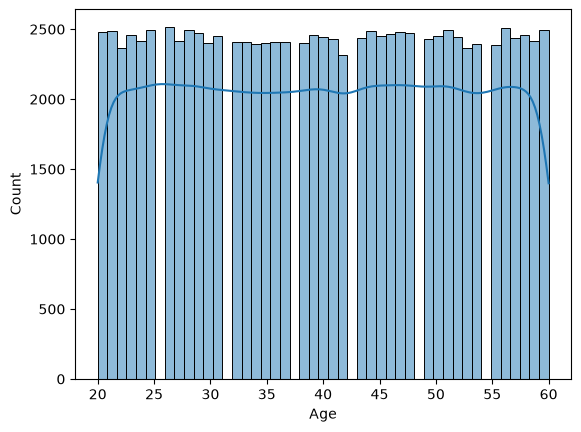

In [81]:
sns.histplot(df["Age"], kde=True)

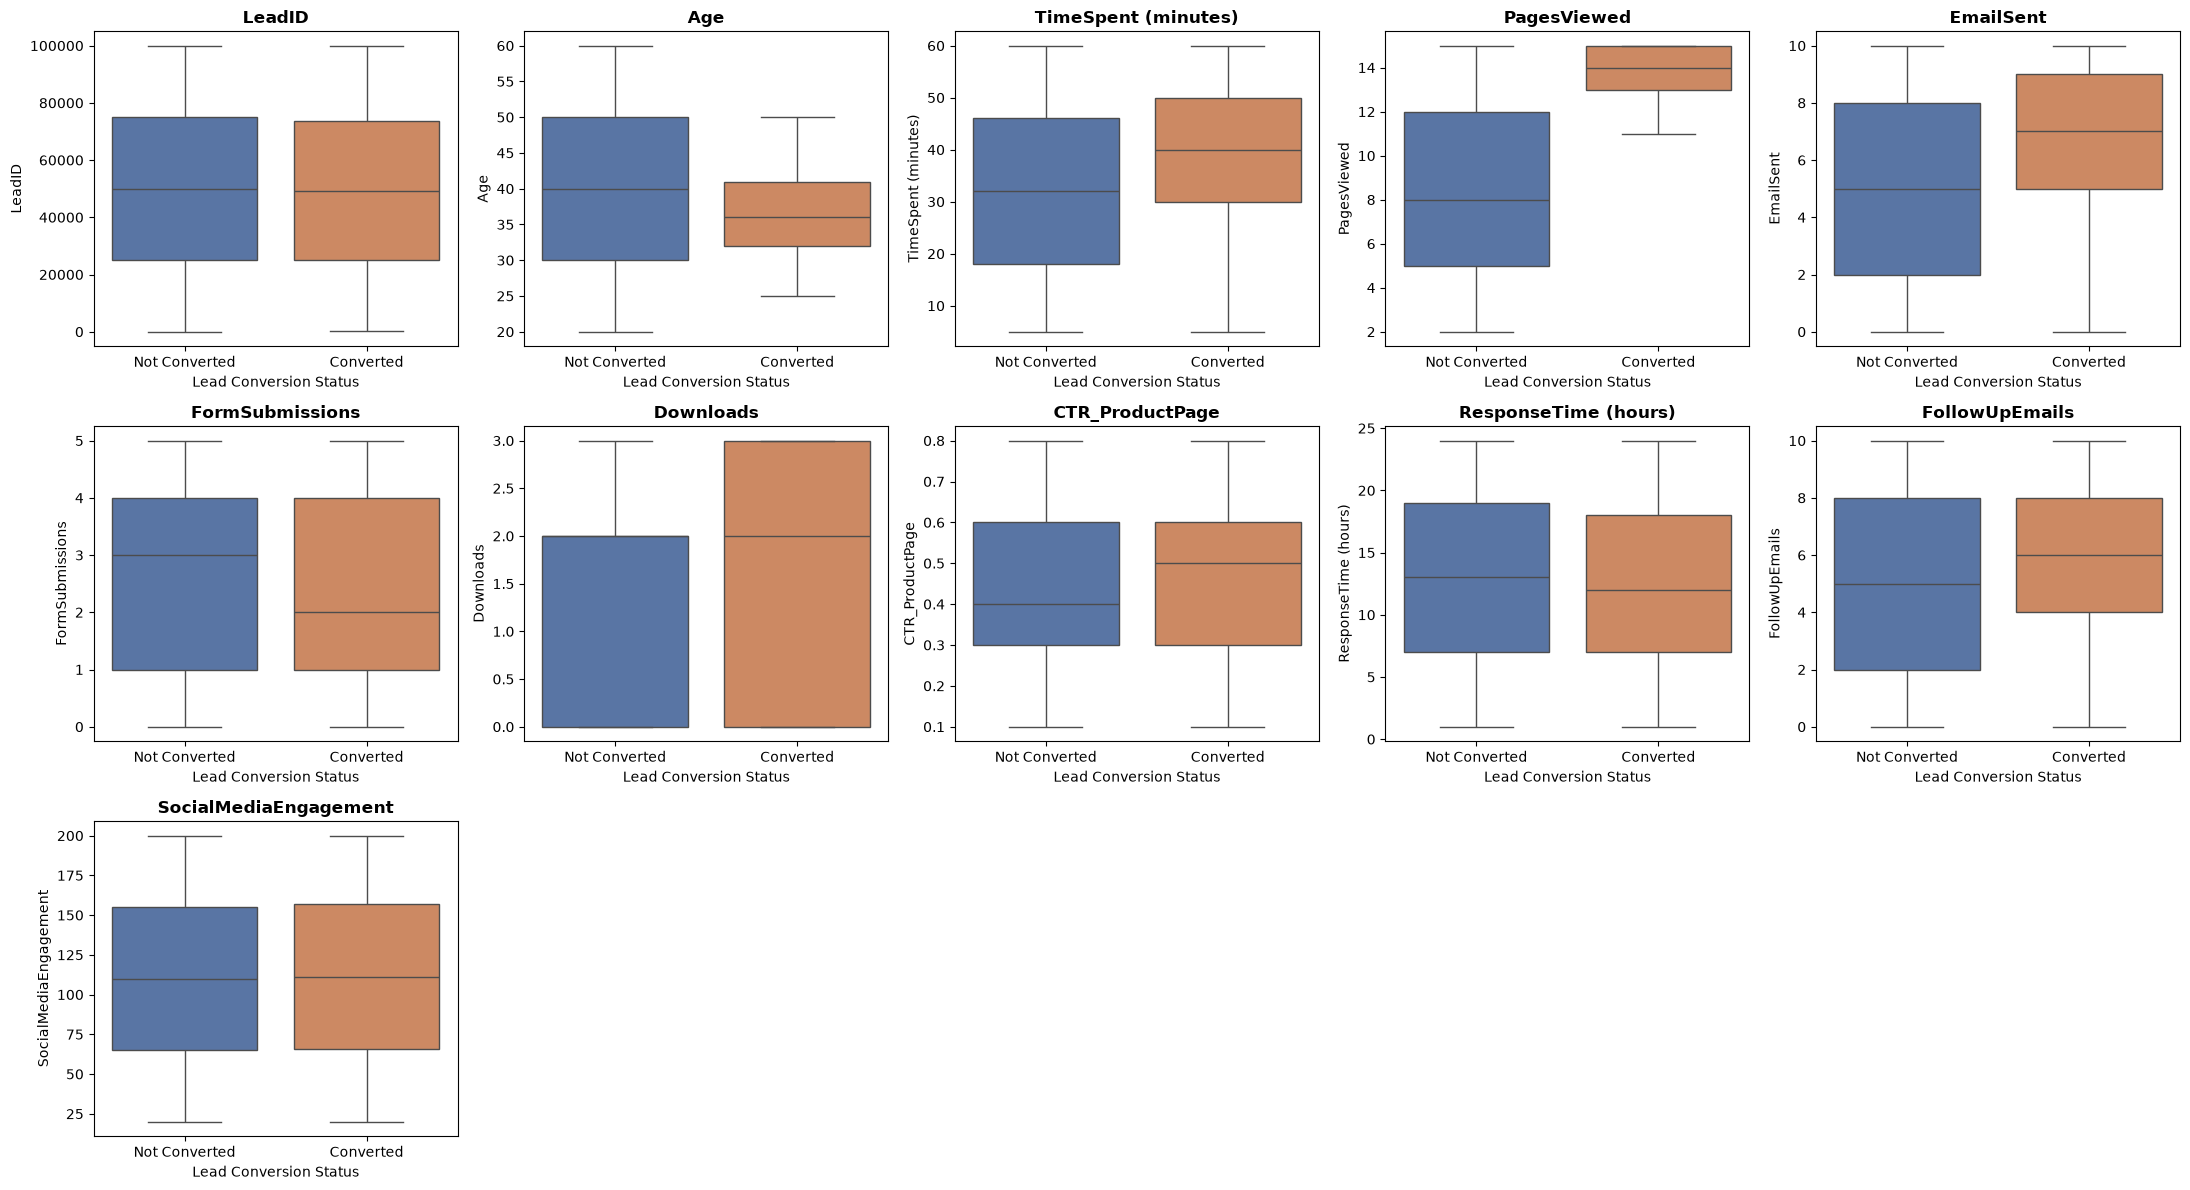

In [82]:
import math

target = 'Conversion (Target)'

# 1. FIXED: Set the number of columns per row you want to display
cols_per_row = 5

# 2. FIXED: Dynamically calculate exactly how many rows are needed
# (e.g., if you have 11 columns, 11/5 = 2.2, math.ceil makes it 3 rows)
num_rows = math.ceil(len(numeric_cols) / cols_per_row)

# 3. FIXED: Create the grid using our calculated rows
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(22, 4 * num_rows))

# 4. Flatten the matrix into a single 1D list for easy looping
axes = axes.flatten()

# 5. Loop over each numeric column and plot it safely
for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=target, 
        y=col, 
        data=df, 
        ax=axes[i], 
        palette=['#4C72B0', '#DD8452'],
        hue=target,          
        legend=False
    )
    
    # Clean up the bottom labels
    axes[i].set_xticks([0, 1])
    
    # Now changing the text labels is safe and completely silent!
    axes[i].set_xticklabels(['Not Converted', 'Converted'])
    
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Lead Conversion Status')
    axes[i].set_ylabel(col)

# 6. FIXED: Automatically delete any remaining empty grid boxes at the end
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


<Axes: xlabel='Conversion (Target)', ylabel='count'>

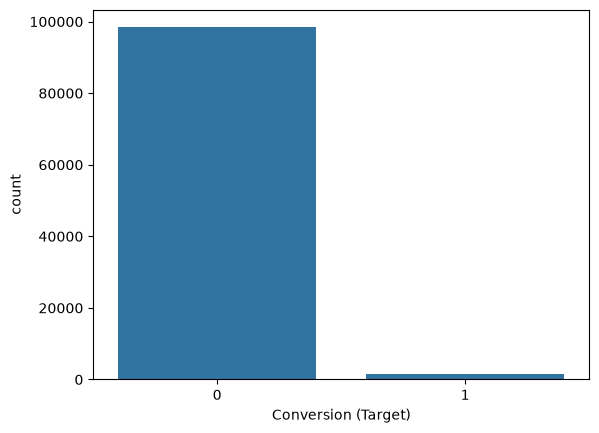

In [83]:
sns.countplot(x=df["Conversion (Target)"]) 

**Bivariate Analysis**

<Axes: xlabel='Gender', ylabel='Age'>

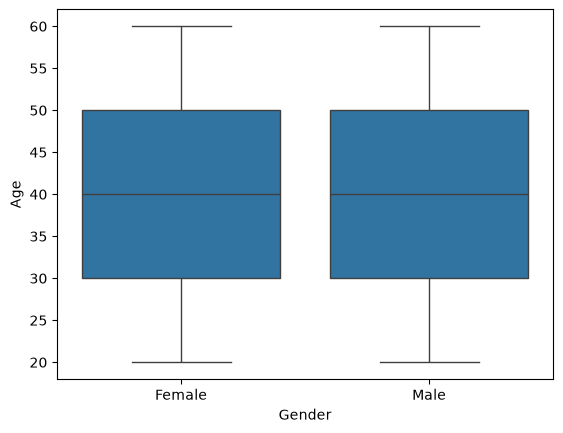

In [84]:
sns.boxplot(x="Gender", y="Age", data=df)

In [85]:
pd.crosstab(df["Gender"], df["Conversion (Target)"])

Conversion (Target),0,1
Gender,,
Female,49081,796
Male,49272,851


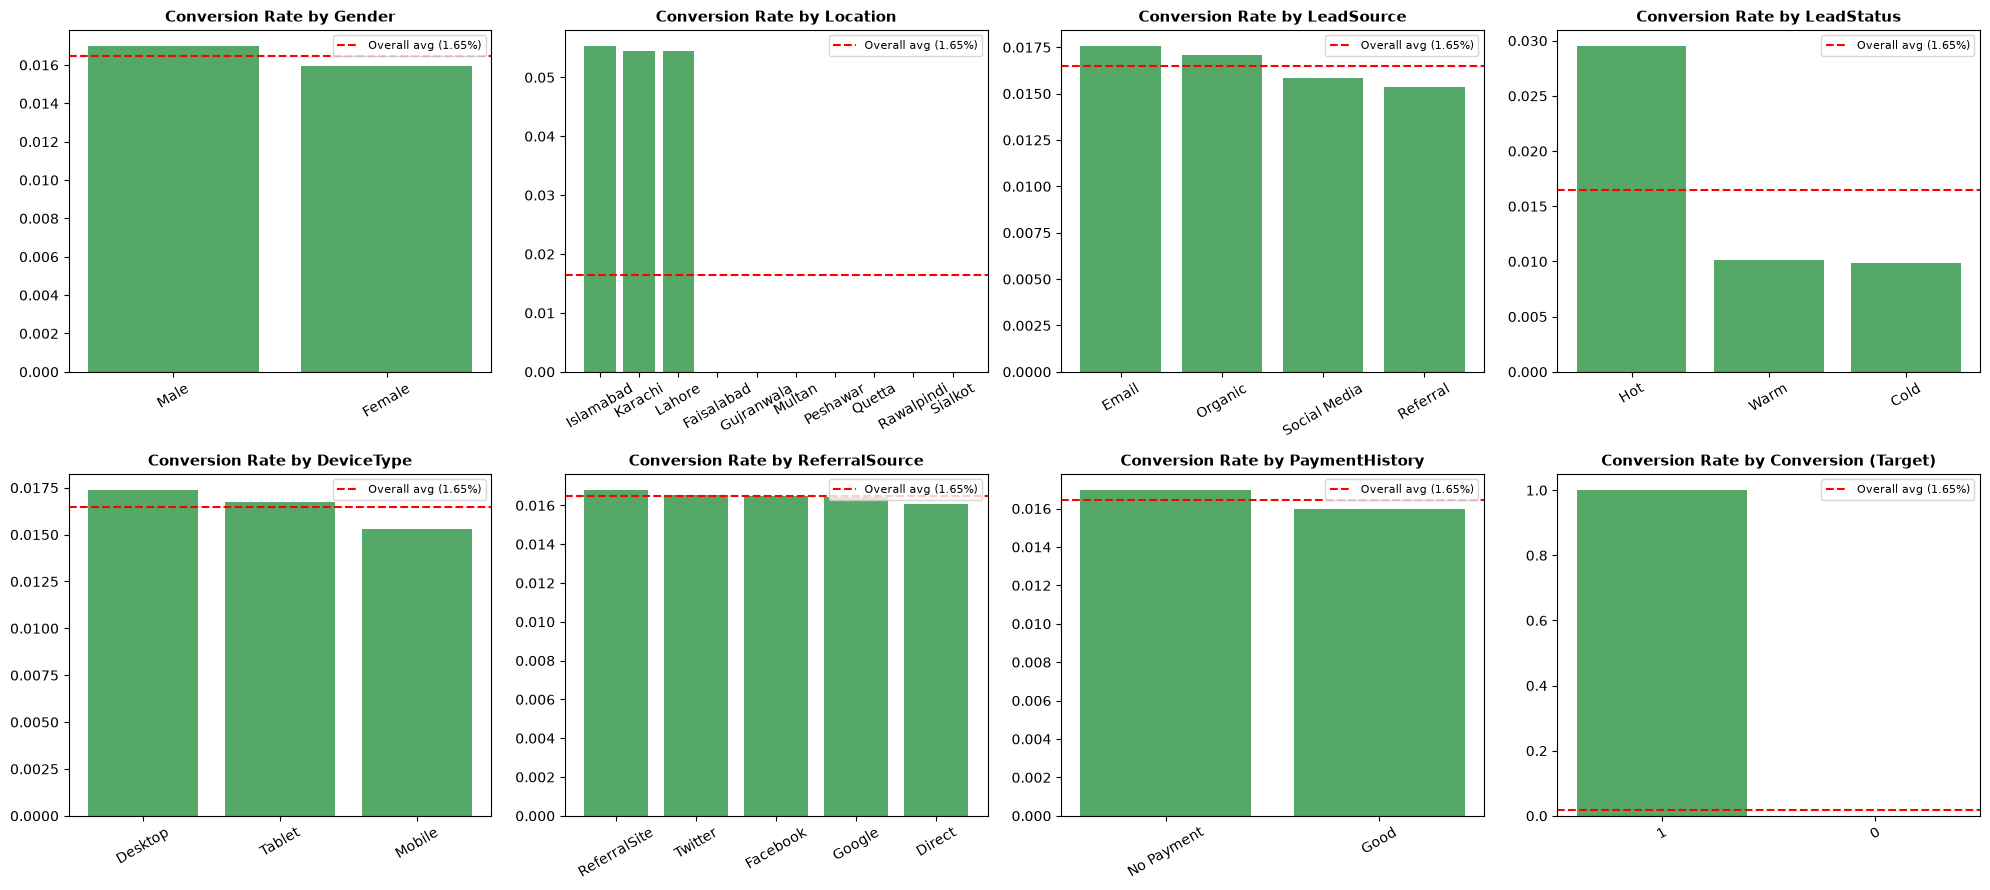

In [86]:
# 1. Define the target variable string name
target = 'Conversion (Target)'

# 2. Set up the exact 2x4 grid grid matching your image
# figsize=(20, 9) ensures room for rotated category names
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

# 3. Flatten the matrix into a single 1D list for easy looping
axes = axes.flatten()

# 4. Loop over each categorical column and plot its conversion rate
for i, col in enumerate(cat_cols):
    # Calculate conversion rate per category and sort descending
    # .mean() on a 0/1 column automatically gives the conversion percentage rate!
    rate = df.groupby(col)[target].mean().sort_values(ascending=False)
    
    # Plot the green bars using your exact custom green color hex code
    axes[i].bar(
        rate.index.astype(str), 
        rate.values, 
        color='#55A868'
    )
    
    # Set titles and formatting
    axes[i].set_title(f'Conversion Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30) # Rotates x-axis words to prevent overlapping text
    
    # Draw the global baseline red dashed line (e.g., your 1.6% dataset average)
    overall_avg = df[target].mean()
    axes[i].axhline(
        overall_avg, 
        color='red', 
        linestyle='--', 
        label=f'Overall avg ({overall_avg:.2%})'
    )
    
    # Place a clean, tiny legend in the corner of each plot slot
    axes[i].legend(fontsize=8)

# 5. Turn off / hide any blank leftover grid boxes 
# (e.g., If you have 7 categorical columns, the 8th box axes[-1] will be hidden cleanly)
for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')

# 6. Apply tight layout to fix spacing and display the dashboard grid
plt.tight_layout()
plt.show()


**Correlation Analysis**

In [87]:
corr = df.corr(numeric_only = True)

<Axes: >

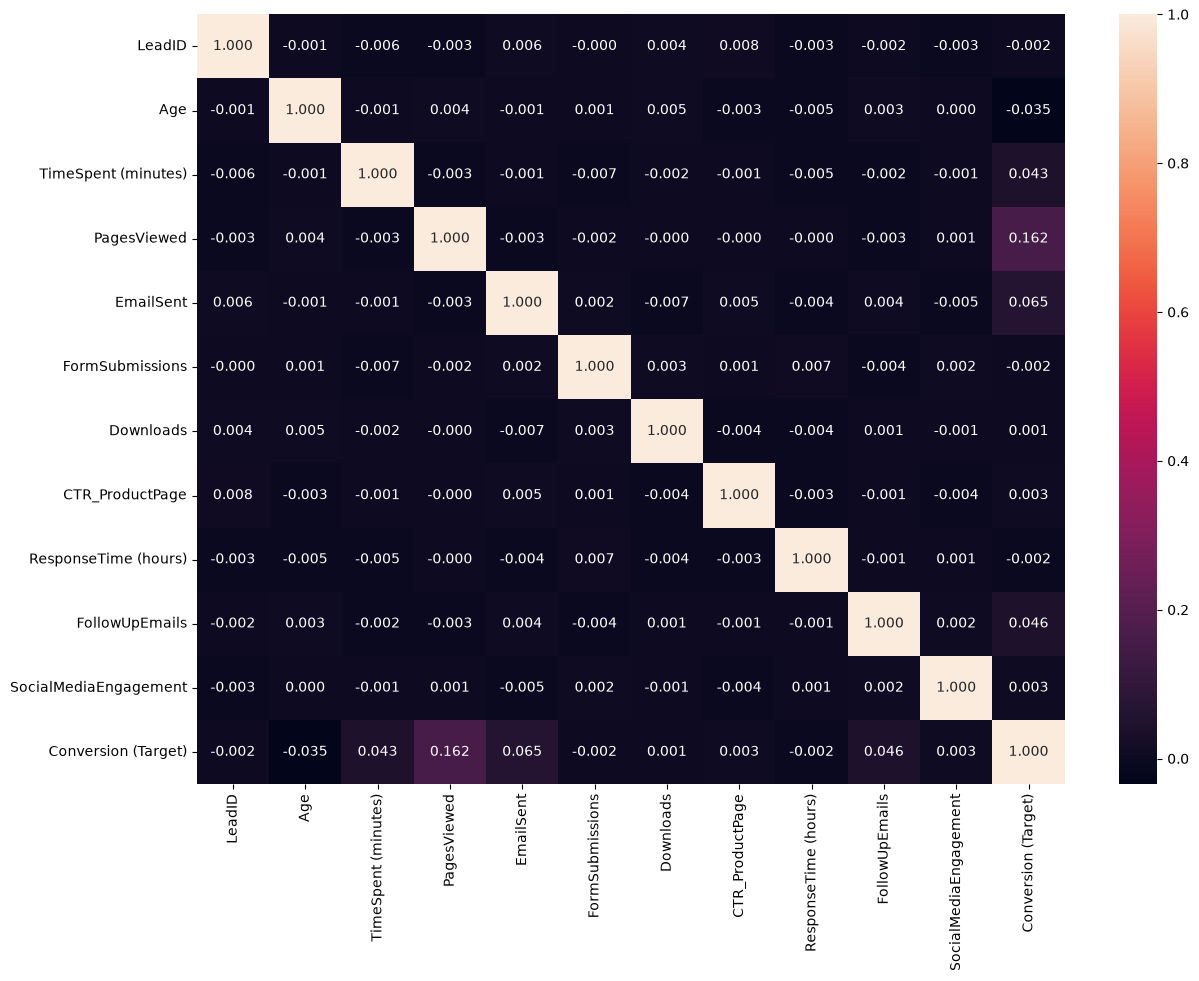

In [88]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".3f")

## `Phase 07 — Outliers Detection`

**Using IQR Method**

In [89]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

outliers = (df[numeric_cols] < lower) | (df[numeric_cols] > upper)
outlier_row = outliers.any(axis=1)
df = df[~outlier_row]
df.shape

(100000, 19)

**Using Zscore Method**

In [90]:
from scipy.stats import zscore
z_score=np.abs(zscore(df[numeric_cols]))
outliers=(z_score>3).any(axis=1)
df=df[~outliers]
df.shape

(100000, 19)

## `Phase 08 — Check Target Variable`

In [91]:
target = "Conversion (Target)"
if target in numeric_cols:
    # Checking Skewness of Target Variable
    sns.histplot(df[target], kde = True)
else:
    print(df[target].value_counts())
    print("")
    print(df[target].value_counts(normalize = True)*100) # Percentage Value


Conversion (Target)
0    98353
1     1647
Name: count, dtype: int64

Conversion (Target)
0    98.353
1     1.647
Name: proportion, dtype: float64


## `Phase 09 — Remove Unnecessary Columns`

In [92]:
# Note: These Un-Necessary Columns are filtered by analyzing feature importance in graph after the complete pipeline execution.Then we update the dataset to improve model performance 

Noisy_Columns = ['LeadID', 'Gender', 'LeadSource', 'DeviceType', 'ReferralSource',
       'FormSubmissions', 'Downloads', 'CTR_ProductPage',
       'ResponseTime (hours)', 'SocialMediaEngagement', 'PaymentHistory']

In [93]:
df.drop(Noisy_Columns, axis=1, inplace=True)

test_data.drop(Noisy_Columns, axis=1, inplace = True)

## `Phase 10 — Train-Test Split`

In [94]:
# As the dataset is already splitted into train and test csv files so we do not need to use train_test_split()
xtrain = df.drop("Conversion (Target)", axis=1)
ytrain = df[["Conversion (Target)"]]

xtest = test_data.drop("Conversion (Target)", axis=1)
ytest = test_data[["Conversion (Target)"]]

## `Phase 11 — Identify Feature Types`

In [95]:
# These Columns are again selected after analysis of model performance so that we give Model only necessary Data
numeric_cols = ['Age', 'TimeSpent (minutes)', 'PagesViewed', 'EmailSent',
 'FollowUpEmails']

cat_cols = ['Location', 'LeadStatus']

In [96]:
# numeric_cols = ['LeadID', 'Age', 'TimeSpent (minutes)', 'PagesViewed', 'EmailSent',
#        'FormSubmissions', 'Downloads', 'ResponseTime (hours)',
#        'FollowUpEmails', 'SocialMediaEngagement']
# cat_cols = ['Gender', 'Location', 'LeadSource', 'LeadStatus', 'DeviceType',
#        'ReferralSource', 'PaymentHistory']

## `Phase 12 — Create Pipeline`

In [97]:
num_pipe = Pipeline(steps=[("Simple_Imputer", SimpleImputer(missing_values=np.nan, strategy="median"))])

cat_pipe = Pipeline(steps=[("Simple_Imputer", SimpleImputer(missing_values=np.nan, strategy="most_frequent")),("Ordinal_Encoder", skp.OrdinalEncoder())])

In [98]:
transformer = ColumnTransformer(transformers=[("Numeric_Pipeline", num_pipe,numeric_cols), ("Categorical_Pipeline", cat_pipe,cat_cols)], remainder = "passthrough") 

In [99]:
pipe = Pipeline(steps=[("Transformer", transformer), ("Model", KNeighborsClassifier())])

## `Phase 13 — Hyperparameter Tuning`

In [100]:
parameters = [
    {
    'Model': [DecisionTreeClassifier(class_weight = "balanced" ,random_state = 42)],
    'Model__criterion': ['gini', 'entropy'],
    'Model__max_depth': [None, 5, 10, 15],
    'Model__min_samples_split': [2, 5, 10]
    },
    
    {
        'Model': [KNeighborsClassifier()],
        'Model__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 19, 23, 27],
        'Model__weights': ['uniform', 'distance'],
        'Model__metric': ['euclidean', 'manhattan', 'minkowski']
    },

    {
        'Model':[RandomForestClassifier(random_state=42)],
        'Model__n_estimators': [50, 100, 200],
        'Model__max_depth': [None, 10, 20],
        'Model__min_samples_split': [2, 5]
    }
]

**Using RandomizedSearchCV**

In [101]:
random_search = ms.RandomizedSearchCV(estimator = pipe, param_distributions = parameters, cv=3, n_iter=10, scoring="f1", n_jobs=-1, random_state=42) 

## `Phase 14 — Train and Test the Selected Model`

In [102]:
random_search.fit(xtrain, ytrain)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'Model': [DecisionTreeC...ndom_state=42)], 'Model__criterion': ['gini', 'entropy'], 'Model__max_depth': [None, 5, ...], 'Model__min_samples_split': [2, 5, ...]}, {'Model': [KNeighborsClassifier()], 'Model__metric': ['euclidean', 'manhattan', ...], 'Model__n_neighbors': [3, 5, ...], 'Model__weights': ['uniform', 'distance']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score

In [103]:
ypred = random_search.predict(xtest) 

**Best Selected Model and it's Tuned Parameters**

In [104]:
# 5. Extract the best performance settings
print(f"Best parameters found: {random_search.best_params_}")

Best parameters found: {'Model__min_samples_split': 5, 'Model__max_depth': 15, 'Model__criterion': 'gini', 'Model': DecisionTreeClassifier(class_weight='balanced', random_state=42)}


In [105]:
best_rf_model = random_search.best_estimator_

## `Phase 16 — Model Evaluation`

In [106]:
print(f"Accuracy Score: {skm.accuracy_score(ytest, ypred):.2f}")
print(f"Precision Score: {skm.precision_score(ytest, ypred):.2f}")
print(f"Recall Score: {skm.recall_score(ytest, ypred):.2f}")
print(f"F1 Score: {skm.f1_score(ytest, ypred):.2f}")

Accuracy Score: 1.00
Precision Score: 1.00
Recall Score: 1.00
F1 Score: 1.00


**Confusion Matrix**

In [107]:
print(f"Confusion Matrix:\n {skm.confusion_matrix(ytest, ypred)}")

Confusion Matrix:
 [[25732     0]
 [    1   412]]


**Classification Report**

In [108]:
# 1. Prints a beautifully formatted text table of all main metrics at once
print(skm.classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25732
           1       1.00      1.00      1.00       413

    accuracy                           1.00     26145
   macro avg       1.00      1.00      1.00     26145
weighted avg       1.00      1.00      1.00     26145



## `Phase 17 — Visualize Model Results`

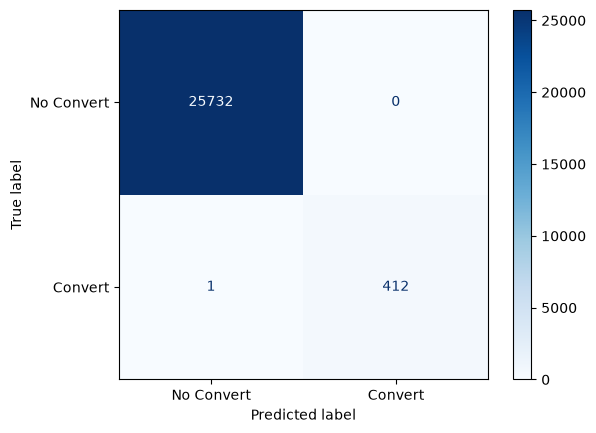

In [109]:
skm.ConfusionMatrixDisplay.from_estimator(random_search, xtest, ytest, cmap = "Blues",display_labels=['No Convert', 'Convert'])

## `Phase 18 — Analyze Feature Importance`

In [110]:
best_pipe = random_search.best_estimator_

winning_model = best_pipe.named_steps["Model"]

processed_columns = best_pipe.named_steps["Transformer"].get_feature_names_out()

# Extracts selected model name string
model_name = winning_model.__class__.__name__

if hasattr(winning_model, 'feature_importances_'):
    importance_values = winning_model.feature_importances_
    importance_type = "Importance Score (0 to 1)"
    
elif hasattr(winning_model, 'coef_'):
    # Flattens coefficients if they are nested in an array layer
    importance_values = np.abs(winning_model.coef_).flatten()
    importance_type = "Absolute Weight Magnitude"
    
else:
    importance_values = None
    print(f"Feature importance extraction not directly supported for: {model_name}")

if importance_values is not None:
    # Clean up the scikit-learn column prefixes (like removing "num_pipeline__")
    clean_columns = [col.split('__')[-1] for col in processed_columns]
    
    feat_imp_df = pd.DataFrame({
        'Feature': clean_columns,
        'Impact_Score': importance_values
    }).sort_values(by='Impact_Score', ascending=False)
    
    print(f"🏆 Top Features Contributing to: {model_name}\n")
    print(feat_imp_df.to_string(index=False))


🏆 Top Features Contributing to: DecisionTreeClassifier

            Feature  Impact_Score
        PagesViewed      0.486453
           Location      0.344146
                Age      0.090807
TimeSpent (minutes)      0.045716
         LeadStatus      0.028138
          EmailSent      0.003510
     FollowUpEmails      0.001231


## `Phase 19 — Visualize Feature Importance`

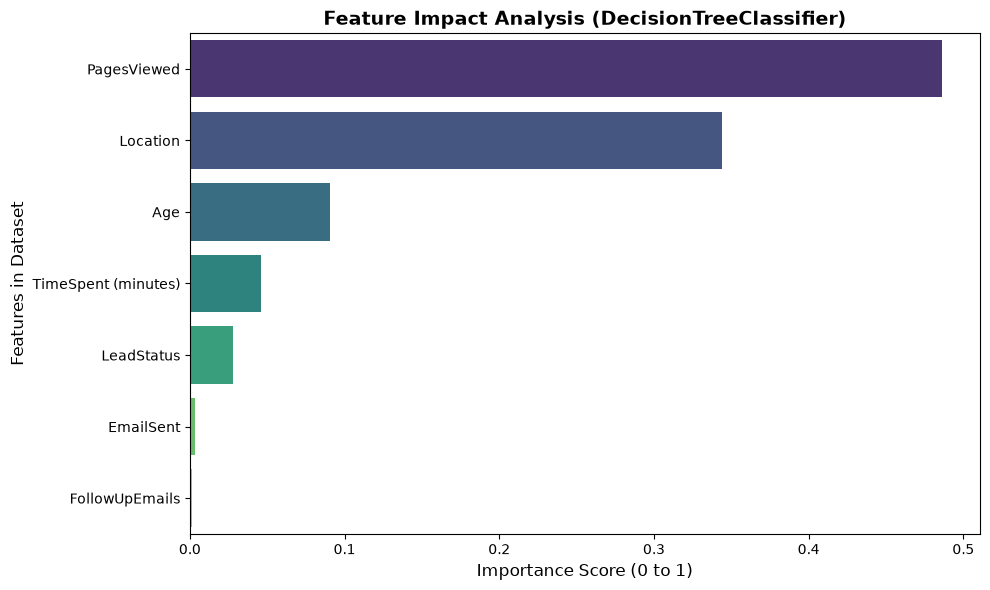

In [111]:
if importance_values is not None:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Impact_Score', 
        y='Feature', 
        data=feat_imp_df, 
        palette='viridis',
        hue='Feature',
        legend=False
    )
    plt.title(f'Feature Impact Analysis ({model_name})', fontsize=14, fontweight='bold')
    plt.xlabel(importance_type, fontsize=12)
    plt.ylabel('Features in Dataset', fontsize=12)
    plt.tight_layout()
    plt.show()

## `Phase 20 — Save & Export the Final Model`

In [112]:
joblib.dump(random_search, "lead_conversion_model")

['lead_conversion_model']

**Now Load the Final Model in python File**

In [113]:
pipeline = joblib.load("lead_conversion_model")

## `Phase 22 — Prediction from User Input`

In [114]:
user_data = { 
    "Age": 32,
    "Location": "Karachi",
    "TimeSpent (minutes)": 60,
    "PagesViewed": 15,
    "LeadStatus": "Hot",
    "EmailSent": 4,
    "FollowUpEmails": 4
}

single_row_df = pd.DataFrame([user_data])

prediction = random_search.predict(single_row_df)

# 4. Map the 1 or 0 prediction array result into a human-readable string
result_text = "CONVERT (Hot Lead)" if prediction[0] == 1 else "NOT CONVERT (Cold Lead)"

print(f"LIVE prediction RESULT: {result_text}")

LIVE prediction RESULT: CONVERT (Hot Lead)
